# 使用 PIL 库将图片拼接成一张大图

In [2]:
from typing import Iterable
import math
import numpy as np
from PIL import Image

## 横向拼接

In [8]:
def concat_horizontal(images: Iterable[Image.Image]) -> Image.Image:

    # 统一高度，按比例缩放
    target_h = min(image.height for image in images)
    resized: list[Image.Image] = []
    for image in images:
        new_w = int(image.width * target_h / image.height)
        resized.append(image.resize((new_w, target_h)))

    total_w = sum(image.width for image in resized)
    result = Image.new("RGB", (total_w, target_h), color=(255, 255, 255))

    x = 0
    for image in resized:
        result.paste(image, (x, 0))
        x += image.width

    return result

## 纵向拼接

In [9]:
def concat_vertical(images: Iterable[Image.Image]) -> Image.Image:

    # 统一宽度，按比例缩放
    target_w = min(image.width for image in images)
    resized = []
    for image in images:
        new_h = int(image.height * target_w / image.width)
        resized.append(image.resize((target_w, new_h)))

    total_h = sum(image.height for image in resized)
    result = Image.new("RGB", (target_w, total_h), color=(255, 255, 255))

    y = 0
    for image in resized:
        result.paste(image, (0, y))
        y += image.height

    return result

## 网格拼接

In [22]:
def concat_grid(
    images: Iterable[Image.Image],
    cols: int = 3,
    cell_size: tuple[int, int] | list[int, int] = (320, 240),
    padding: int = 10,
    bg_color: tuple[int, int, int] | list[int, int, int] = (255, 255, 255),
) -> Image.Image:

    rows = math.ceil(len(images) / cols)

    cell_w, cell_h = cell_size
    out_w = cols * cell_w + (cols + 1) * padding
    out_h = rows * cell_h + (rows + 1) * padding

    result = Image.new("RGB", (out_w, out_h), bg_color)

    for idx, image in enumerate(images):
        row = idx // cols
        col = idx % cols

        # 等比例缩放到 cell 内部
        image.thumbnail((cell_w, cell_h))

        x = padding + col * (cell_w + padding) + (cell_w - image.width) // 2
        y = padding + row * (cell_h + padding) + (cell_h - image.height) // 2

        result.paste(image, (x, y))

    return result

## test

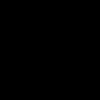

In [23]:
image1 = Image.fromarray(np.full((100, 100, 3), 0, dtype=np.uint8))
image1

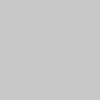

In [24]:
image2 = Image.fromarray(np.full((100, 100, 3), 200, dtype=np.uint8))
image2

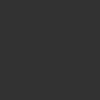

In [25]:
image3 = Image.fromarray(np.full((100, 100, 3), fill_value=50, dtype=np.uint8))
image3

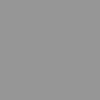

In [26]:
image4 = Image.fromarray(np.full((100, 100, 3), fill_value=150, dtype=np.uint8))
image4

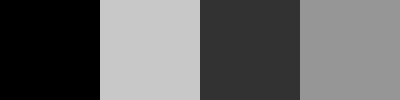

In [27]:
concat_horizontal([image1, image2, image3, image4])

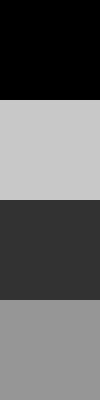

In [28]:
concat_vertical([image1, image2, image3, image4])

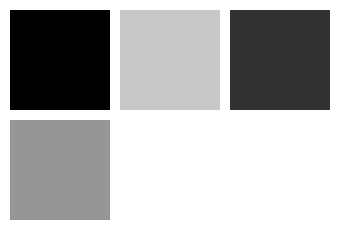

In [29]:
concat_grid([image1, image2, image3, image4], 3, (100, 100))